In [3]:
import os, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

print(f"Imported all the libraries!")

Imported all the libraries!


In [4]:
print(f"PyTorch version : {torch.__version__}")
print(f"GPU Available   : {torch.cuda.is_available()}")
print(f"Device Name     : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.4.1+cu124
GPU Available   : True
Device Name     : NVIDIA A40


In [6]:
class CFG:
    # Paths 
    DATA_DIR = "/workspace/melanoma/data"
    TRAIN_DIR = "/workspace/melanoma/data/train"
    TEST_DIR = "/workspace/melanoma/data/test"
    TRAIN_CSV = "/workspace/melanoma/data/train.csv"
    MODEL_PATH = "/workspace/melanoma/models/effnet_b4_best.pth"
    OUTPUT_DIR = "/workspace/melanoma/outputs"

    # Model 
    MODEL_NAME = "efficientnet_b4"
    PRETRAINED = True
    IMG_SIZE = 380        # EfficientNet-B4 native resolution
    DROP_RATE = 0.4

    # Training 
    SEED = 123
    EPOCHS = 15
    BATCH_SIZE = 16         # smaller — B4 is bigger model
    LR = 3e-4
    NUM_WORKERS = 4

    # Focal loss
    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0

    # Device 
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# Set seeds 
random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
torch.cuda.manual_seed_all(CFG.SEED)
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

print(f"Model: {CFG.MODEL_NAME}")
print(f"Image size: {CFG.IMG_SIZE}x{CFG.IMG_SIZE}")
print(f"Batch size: {CFG.BATCH_SIZE}")
print(f"Device: {CFG.DEVICE}")

Model: efficientnet_b4
Image size: 380x380
Batch size: 16
Device: cuda


In [10]:
df = pd.read_csv(CFG.TRAIN_CSV)

print(f"Total samples: {len(df)}")
print(f"Positive (malignant): {df['target'].sum()} ({df['target'].mean()*100:.2f}%)")
print(f"Negative (benign): {(df['target']==0).sum()}")

# Stratified split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=CFG.SEED,
    stratify=df['target']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\nTrain size: {len(train_df)} | Malignant: {train_df['target'].sum()}")
print(f"Val size: {len(val_df)} | Malignant: {val_df['target'].sum()}")

Total samples: 33126
Positive (malignant): 584 (1.76%)
Negative (benign): 32542

Train size: 26500 | Malignant: 467
Val size: 6626 | Malignant: 117


In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        pt = torch.exp(-bce_loss) # probability of correct class           
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

In [12]:
# Quick sanity check
dummy_input = torch.randn(4)
dummy_target = torch.tensor([0.0, 1.0, 0.0, 1.0])
criterion = FocalLoss()
loss = criterion(dummy_input, dummy_target)

print(f"Focal Loss defined!")
print(f"Alpha: {CFG.FOCAL_ALPHA} (down-weights easy negatives)")
print(f"Gamma: {CFG.FOCAL_GAMMA} (focusing parameter)")
print(f"Sanity check loss: {loss.item():.4f}")

Focal Loss defined!
Alpha: 0.25 (down-weights easy negatives)
Gamma: 2.0 (focusing parameter)
Sanity check loss: 0.0392


In [13]:
# Transformers

train_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Transpose(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=38, max_width=38, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [14]:
# Datasets 

class MelanomaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transforms=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        record = self.dataframe.iloc[idx]
        img_path = os.path.join(self.img_dir, record['image_name'] + '.jpg')
        img = np.array(Image.open(img_path).convert('RGB'))
        label = torch.tensor(record['target'], dtype=torch.float32)
        if self.transforms:
            img = self.transforms(image=img)['image']
        return img, label

In [15]:
# DataLoaders

train_dataset = MelanomaDataset(train_df, CFG.TRAIN_DIR, transforms=train_transforms)
val_dataset   = MelanomaDataset(val_df,   CFG.TRAIN_DIR, transforms=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

imgs, lbls = next(iter(train_loader))
print(f"\nBatch image shape: {imgs.shape}")
print(f"Batch label shape: {lbls.shape}")

Train batches: 1657
Val batches: 415

Batch image shape: torch.Size([16, 3, 380, 380])
Batch label shape: torch.Size([16])


In [16]:
class EfficientNetB4(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            CFG.MODEL_NAME, 
            pretrained=CFG.PRETRAINED, 
            num_classes=0
        )
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1) if False else nn.Identity(),
            nn.Dropout(p=CFG.DROP_RATE),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

model = EfficientNetB4().to(CFG.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {CFG.MODEL_NAME}")
print(f"Total params: {total_params:,}")
print(f"Trainable: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Model: efficientnet_b4
Total params: 18,007,881
Trainable: 18,007,881


In [17]:
criterion = FocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CFG.LR,
    steps_per_epoch=len(train_loader),
    epochs=CFG.EPOCHS,
    pct_start=0.1
)

print(f"Loss: FocalLoss (alpha={CFG.FOCAL_ALPHA}, gamma={CFG.FOCAL_GAMMA})")
print(f"Optimizer: AdamW (lr={CFG.LR}, weight_decay=1e-4)")
print(f"Scheduler: OneCycleLR (max_lr={CFG.LR})")

Loss: FocalLoss (alpha=0.25, gamma=2.0)
Optimizer: AdamW (lr=0.0003, weight_decay=1e-4)
Scheduler: OneCycleLR (max_lr=0.0003)


In [18]:
def run_training(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, y_true, y_pred = 0, [], []

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)

        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(torch.sigmoid(logits).detach().cpu().numpy())

    return total_loss / len(loader), roc_auc_score(y_true, y_pred)


def run_validation(model, loader, criterion):
    model.eval()
    total_loss, y_true, y_pred = 0, [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
            logits = model(imgs).squeeze(1)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.sigmoid(logits).detach().cpu().numpy())

    return total_loss / len(loader), roc_auc_score(y_true, y_pred)

print("Training and validation functions ready!")

Training and validation functions ready!


In [19]:
# Training block

history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
best_auc, best_epoch = 0.0, 0

for epoch in range(1, CFG.EPOCHS + 1):
    train_loss, train_auc = run_training(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_auc = run_validation(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    if val_auc > best_auc:
        best_auc, best_epoch = val_auc, epoch
        torch.save(model.state_dict(), CFG.MODEL_PATH)
        tag = " | Saved"
    else:
        tag = ""

    print(f"Epoch [{epoch:02d}/{CFG.EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}{tag}")

print(f"\nBest Val AUC: {best_auc:.4f} at Epoch {best_epoch}")

Epoch [01/15] Train Loss: 0.0085 | Train AUC: 0.6932 | Val Loss: 0.0056 | Val AUC: 0.8496 | Saved
Epoch [02/15] Train Loss: 0.0054 | Train AUC: 0.8460 | Val Loss: 0.0053 | Val AUC: 0.8676 | Saved
Epoch [03/15] Train Loss: 0.0050 | Train AUC: 0.8733 | Val Loss: 0.0051 | Val AUC: 0.8837 | Saved
Epoch [04/15] Train Loss: 0.0046 | Train AUC: 0.9012 | Val Loss: 0.0054 | Val AUC: 0.8623
Epoch [05/15] Train Loss: 0.0045 | Train AUC: 0.9083 | Val Loss: 0.0055 | Val AUC: 0.8870 | Saved
Epoch [06/15] Train Loss: 0.0040 | Train AUC: 0.9314 | Val Loss: 0.0051 | Val AUC: 0.8889 | Saved
Epoch [07/15] Train Loss: 0.0036 | Train AUC: 0.9494 | Val Loss: 0.0058 | Val AUC: 0.8990 | Saved
Epoch [08/15] Train Loss: 0.0031 | Train AUC: 0.9669 | Val Loss: 0.0058 | Val AUC: 0.9053 | Saved
Epoch [09/15] Train Loss: 0.0027 | Train AUC: 0.9745 | Val Loss: 0.0055 | Val AUC: 0.9100 | Saved
Epoch [10/15] Train Loss: 0.0022 | Train AUC: 0.9856 | Val Loss: 0.0077 | Val AUC: 0.8941
Epoch [11/15] Train Loss: 0.0018 | T

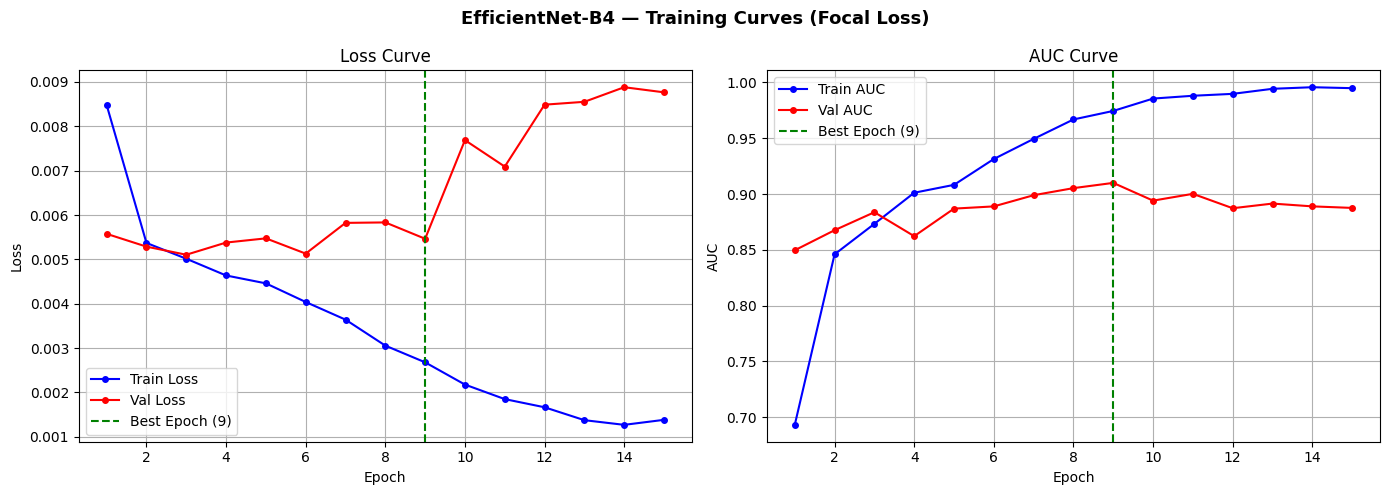

Saved!


In [20]:
epochs = range(1, CFG.EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history['train_auc'], 'b-o', label='Train AUC', markersize=4)
axes[1].plot(epochs, history['val_auc'],   'r-o', label='Val AUC',   markersize=4)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].set_title('AUC Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('EfficientNet-B4 — Training Curves (Focal Loss)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG.OUTPUT_DIR}/b4_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [21]:
model.load_state_dict(torch.load(CFG.MODEL_PATH))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(CFG.DEVICE)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_binary = (y_pred >= 0.5).astype(int)

print(f"Val AUC: {roc_auc_score(y_true, y_pred):.4f}")
print(f"Predicted malignant: {y_binary.sum()} / {len(y_binary)}")
print(f"Actual malignant: {int(y_true.sum())}")

/tmp/ipykernel_4580/845228191.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CFG.MODEL_PATH))


Val AUC: 0.9100
Predicted malignant: 71 / 6626
Actual malignant: 117


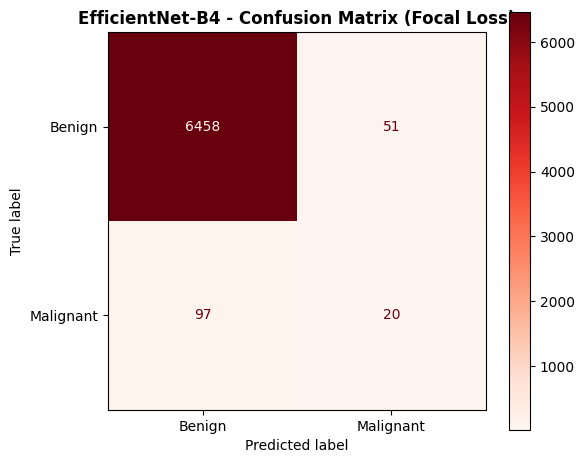


Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      6509
   Malignant       0.28      0.17      0.21       117

    accuracy                           0.98      6626
   macro avg       0.63      0.58      0.60      6626
weighted avg       0.97      0.98      0.97      6626



In [22]:
cm = confusion_matrix(y_true, y_binary)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax, cmap='Reds', values_format='d')
ax.set_title('EfficientNet-B4 - Confusion Matrix (Focal Loss)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG.OUTPUT_DIR}/b4_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_binary, target_names=['Benign', 'Malignant']))

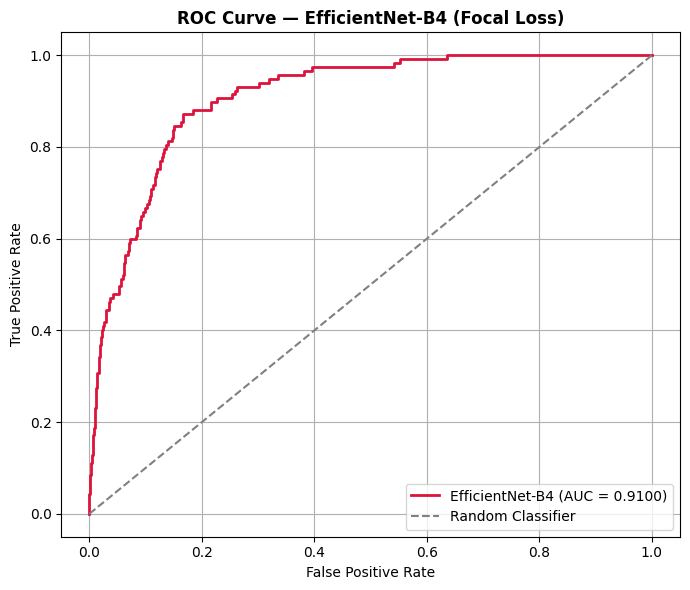

Saved!


In [23]:
fpr, tpr, _ = roc_curve(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'EfficientNet-B4 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — EfficientNet-B4 (Focal Loss)', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{CFG.OUTPUT_DIR}/b4_roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")